In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
data = pd.read_csv(r"C:\Users\divya\OneDrive\Documents\Experiments\Exp-10\ratings.csv")

print("Dataset Loaded")
data.head()

Dataset Loaded


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [3]:
user_item_matrix = data.pivot(index='userId',
                             columns='movieId',
                             values='rating')

# Fill missing values (IMPORTANT for NMF)
matrix_filled = user_item_matrix.fillna(0)

print("Matrix Shape:", matrix_filled.shape)
matrix_filled.head()

Matrix Shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,4.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
k = 20  # latent features

nmf = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = nmf.fit_transform(matrix_filled)   # User-feature matrix
H = nmf.components_                    # Item-feature matrix

In [5]:
nmf_reconstructed = np.dot(W, H)

nmf_reconstructed[:5, :5]

array([[2.43541898e+00, 1.04812570e+00, 1.01208665e+00, 4.01446536e-02,
        3.21829203e-01],
       [2.78371635e-01, 1.26101070e-01, 0.00000000e+00, 0.00000000e+00,
        1.84139492e-02],
       [8.71979932e-02, 3.94240674e-02, 2.86661573e-02, 1.88447673e-06,
        1.71292173e-05],
       [1.95411012e+00, 3.57105820e-01, 3.14678446e-01, 6.54730784e-02,
        3.64281157e-01],
       [9.30768325e-01, 9.94130697e-01, 2.96295391e-01, 8.72118856e-02,
        3.28511031e-01]])

In [6]:
rmse_nmf = np.sqrt(mean_squared_error(matrix_filled, nmf_reconstructed))
mae_nmf = mean_absolute_error(matrix_filled, nmf_reconstructed)

print("NMF RMSE:", rmse_nmf)
print("NMF MAE :", mae_nmf)

NMF RMSE: 0.3594501132286364
NMF MAE : 0.08070798443888559


In [7]:
def recommend_nmf(user_id, n=5):
    user_ratings = nmf_reconstructed[user_id - 1]
    top_items = np.argsort(user_ratings)[-n:][::-1]
    return top_items

print("Top 5 Recommendations for User 1:")
print(recommend_nmf(1))

Top 5 Recommendations for User 1:
[897 224 910 899 507]


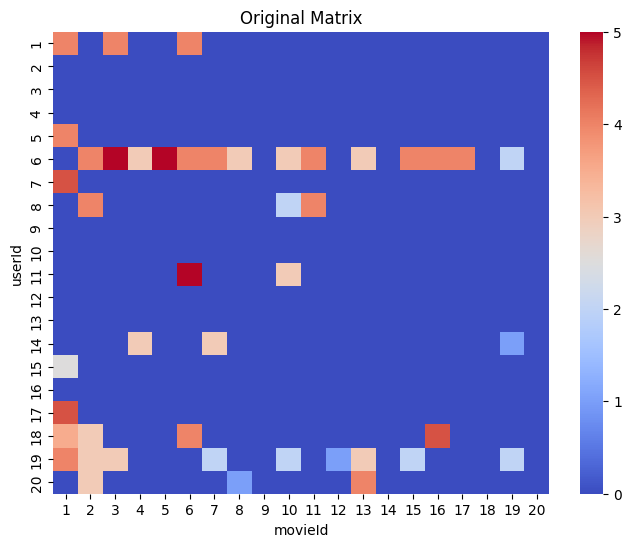

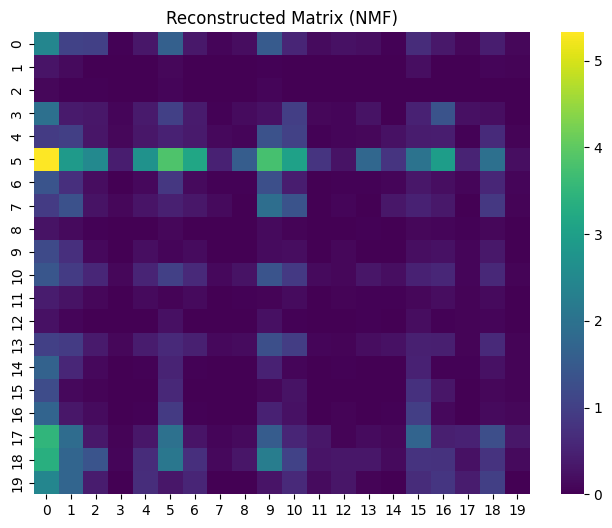

In [8]:
plt.figure(figsize=(8,6))
sns.heatmap(matrix_filled.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(nmf_reconstructed[:20, :20], cmap="viridis")
plt.title("Reconstructed Matrix (NMF)")
plt.show()

In [9]:
def precision_recall_at_k(actual, predicted, k=5):
    pred_k = predicted[:k]
    precision = len(set(pred_k) & set(actual)) / k
    recall = len(set(pred_k) & set(actual)) / len(actual)
    return precision, recall

# Example
actual_items = [1, 2, 3]
predicted_items = recommend_nmf(1)

precision, recall = precision_recall_at_k(actual_items, predicted_items)

print("Precision:", precision)
print("Recall   :", recall)

Precision: 0.0
Recall   : 0.0


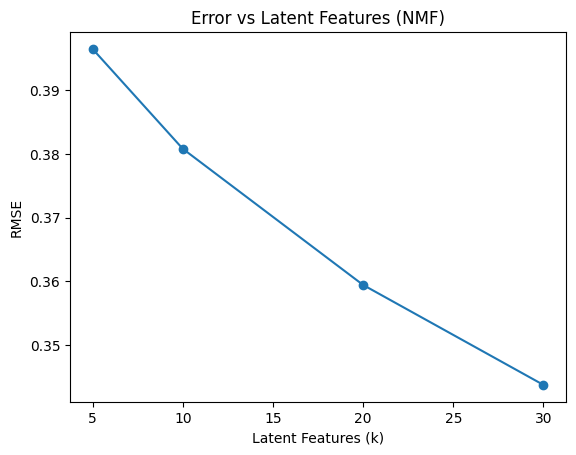

In [12]:
k_values = [5, 10, 20, 30]
rmse_list = []

for k in k_values:
    nmf_temp = NMF(n_components=k, init='random', random_state=42, max_iter=500)
    W_temp = nmf_temp.fit_transform(matrix_filled)
    H_temp = nmf_temp.components_

    reconstructed = np.dot(W_temp, H_temp)
    rmse = np.sqrt(mean_squared_error(matrix_filled, reconstructed))
    rmse_list.append(rmse)

plt.plot(k_values, rmse_list, marker='o')
plt.xlabel("Latent Features (k)")
plt.ylabel("RMSE")
plt.title("Error vs Latent Features (NMF)")
plt.show()